In [1]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.5 MB/s eta 0:00:00


2025-03-11 12:03:06.729 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.183 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-03-11 12:03:07.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.194 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.195 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-03-11 12:03:07.197 Thread 'MainThread': mi

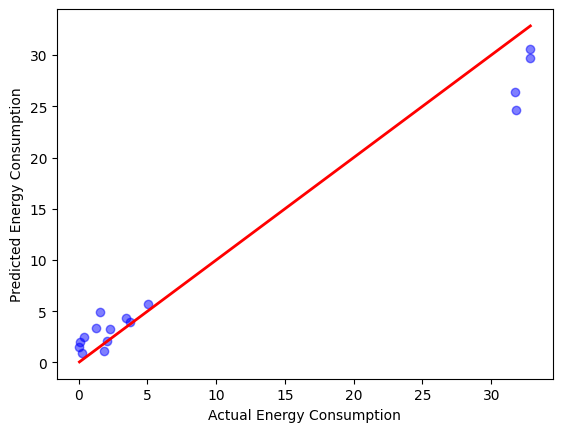

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import streamlit as st

# Load dataset
file_path = "owid-energy-data.csv"
df = pd.read_csv(file_path)

# Display column names to check the correct column name for energy consumption
st.write("Dataset Columns:", df.columns.tolist())

# Identify the correct column for energy consumption
energy_columns = [col for col in df.columns if "consumption" in col.lower()]
if not energy_columns:
    raise KeyError("No column related to energy consumption found in the dataset.")

# Use the first identified energy consumption column
energy_column = energy_columns[0]
st.write(f"Using '{energy_column}' as the target variable.")

# Preprocess data
df.dropna(inplace=True)

# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define features and target variable
X = df.drop(columns=[energy_column])
y = df[energy_column]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Streamlit app
st.title('Energy Consumption Prediction')
st.write(f'MSE: {mse:.2f}, R-squared: {r2:.2f}')

# Visualization
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.5, color='blue')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r', lw=2)
ax.set_xlabel('Actual Energy Consumption')
ax.set_ylabel('Predicted Energy Consumption')
st.pyplot(fig)

# User input for prediction
st.sidebar.header('Predict Energy Consumption')
features = {col: st.sidebar.number_input(f'Enter {col}:',
float(df[col].min()), float(df[col].max())) for col in X.columns}

if st.sidebar.button('Predict'):
    input_data = np.array([features[col] for col in X.columns]).reshape(1, - 1)
    prediction = model.predict(input_data)[0]
    st.sidebar.write(f'Predicted Energy Consumption: {prediction:.2f} kWh')